<a href="https://colab.research.google.com/github/roughhawkbit/digi-inno-road-prod/blob/main/analysis/Analyse_BART_zero_shot_results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup

In [1]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

In [2]:
import matplotlib
import numpy
import os
import pandas
import sys

In [3]:
if IN_COLAB:
  dirpath = '/content/digi-inno-road-prod'
  if not os.path.isdir(dirpath):
    # TODO git pull
    !git clone https://github.com/roughhawkbit/digi-inno-road-prod.git
  sys.path.insert(0,dirpath)
else:
  module_path = os.path.abspath(os.path.join('..'))
  if not module_path in sys.path:
      sys.path.insert(0, module_path)

Cloning into 'digi-inno-road-prod'...
remote: Enumerating objects: 709, done.
remote: Counting objects: 100% (125/125), done.
remote: Compressing objects: 100% (118/118), done.
remote: Total 709 (delta 80), reused 14 (delta 7), pack-reused 584 (from 1)
Receiving objects: 100% (709/709), 2.09 MiB | 6.82 MiB/s, done.
Resolving deltas: 100% (445/445), done.


In [4]:
from innoprod.sheet_tools import get_sheet_dfs
from innoprod.plotting_tools import rand_jitter

# Read in data

In [5]:
all_results_df = get_sheet_dfs(
    sheet_id="1_ycDOfNq7khbzgdgF80qhHWmWpHC_9TGIwdDkkAvfvY",
    ranges={"Results": "Sheet1!A1:H7756"}
  )['Results']
# all_results_df

In [6]:
col_types = {
    'Client ID': 'str',
    'Current DRS': pandas.Int64Dtype(),
    'Core': 'str',
    'Category': 'str',
    'Question': 'str',
    'Prediction': 'int',
    'Probability': 'float',
    'Confidence': 'float'
}

all_results_df['Current DRS'] = all_results_df['Current DRS'].replace(to_replace='', value=numpy.nan)

for col, ty in col_types.items():
  all_results_df[col] = all_results_df[col].astype(ty)
# all_results_df

In [7]:
all_results_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7755 entries, 0 to 7754
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Client ID    7755 non-null   object 
 1   Current DRS  7080 non-null   Int64  
 2   Core         7755 non-null   object 
 3   Category     7755 non-null   object 
 4   Question     7755 non-null   object 
 5   Prediction   7755 non-null   int64  
 6   Probability  7755 non-null   float64
 7   Confidence   7755 non-null   float64
dtypes: Int64(1), float64(2), int64(1), object(4)
memory usage: 492.4+ KB


In [25]:
questions_prompts = get_sheet_dfs(
    sheet_id="18oFiC2gu6azFaO1XHYFsSpVovBvz08s0hgg97Lu1LGY",
    ranges={"QuestionsPrompts": "Sheet1!A1:G16"}
  )['QuestionsPrompts']

# Correlations between questions in same W/C/C Core

In [32]:
questions_prompts['Core'] = questions_prompts['Core'].astype('category')
questions_prompts['Core'] = questions_prompts['Core'].cat.set_categories(['Willingness', 'Capability', 'Capacity'], ordered=True)

In [45]:
ordered_questions = questions_prompts[['Core',	'Category',	'Question']].sort_values(['Core', 'Category'])['Question'].to_list()
# ordered_questions

In [46]:
corr_df = all_results_df.sort_values(by='Question')[['Client ID', 'Question', 'Prediction']].pivot(index='Client ID', columns='Question', values='Prediction') #.corr()
corr_df = corr_df.reindex(ordered_questions, axis=1)
corr_df = corr_df.corr()
corr_df

Question,Does the company have a clear strategy to utilise advanced technologies to support growth and competitiveness?,Is the management team of the company open to working with academic or public organisations/networks to acquire new knowledge?,Are continuous improvement methods embedded within the culture of the company's management and workforce in relation to technology and digital transformation?,Is the company aware of the possibilities offered by emerging technologies and has it identified commercially-viable opportunities where they could add value to its current business?,"Is the company willing to invest time and resources to introduce new skills or knowledge into its workforce through staff training, new recruitment, or apprenticeship schemes?",Is the company able to offer its customers specialised products or services that differentiates it from competitors?,Does the company have a range of managerial skills and experience to translate its resources and capabilities into a competitive position within the market?,"Does the company have efficient processes and related systems in appropriate areas (e.g. enterprise resource planning, quality-management, customer-relationship-management, etc.)?",Does the company currently utilise any advanced technological capabilities that give it an advantage over competitors?,Does the company have any highly-specialised skills and knowledge within the workforce that give it an advantage over competitors?,Does the company have long-term key customers that gives it the stability to plan for the future?,Does the management of the company (especially if it is not the same as the ownership) have sufficient decision making authority to introduce the changes needed for its growth strategy?,Does the company have the flexibility in its structures and processes to introduce new products or services in a way that minimises risk and potential disruption to BAU?,Does the company currently have the resources available to invest in new technologies and implement them in a cost-effective way?,Does the workforce of the company have the appropriate know-how to be able to facilitate the introduction of new technology or processes?
Question,,,,,,,,,,,,,,,
Does the company have a clear strategy to utilise advanced technologies to support growth and competitiveness?,1.000000,-0.132409,0.049576,0.075032,0.027058,0.256221,-0.050075,0.113799,0.010884,-0.062671,0.026092,-0.008846,-0.104682,-0.020706,0.089129
Is the management team of the company open to working with academic or public organisations/networks to acquire new knowledge?,-0.132409,1.000000,0.579198,0.590470,0.448806,-0.005102,0.636477,0.289409,0.031496,0.544510,0.180369,0.221108,0.799728,0.673671,0.603922
Are continuous improvement methods embedded within the culture of the company's management and workforce in relation to technology and digital transformation?,0.049576,0.579198,1.000000,0.563937,0.399618,0.191046,0.602055,0.331775,0.009506,0.438182,0.173685,0.217090,0.605180,0.605561,0.605043
Is the company aware of the possibilities offered by emerging technologies and has it identified commercially-viable opportunities where they could add value to its current business?,0.075032,0.590470,0.563937,1.000000,0.414307,0.098274,0.615498,0.330650,0.017477,0.402229,0.185322,0.175389,0.649117,0.609247,0.549792
"Is the company willing to invest time and resources to introduce new skills or knowledge into its workforce through staff training, new recruitment, or apprenticeship schemes?",0.027058,0.448806,0.399618,0.414307,1.000000,0.084229,0.417437,0.270527,0.009487,0.262488,0.110456,0.040608,0.466895,0.458013,0.370034
Is the company able to offer its customers specialised products or services that differentiates it from competitors?,0.256221,-0.005102,0.191046,0.098274,0.084229,1.000000,0.066588,0.025969,0.031766,0.044211,0.032531,-0.081886,-0.005176,0.080976,0.085739
Does the company have a range of managerial skills and experience to translate its re

In [48]:
if IN_COLAB:
  output_dir = os.path.join(dirpath, 'analysis', 'outputs')

corr_df.to_csv(os.path.join(output_dir, 'BART_WCC_question-question_correlations_byCore.csv'), index=False)

In [49]:
ordered_questions = questions_prompts[['Core',	'Category',	'Question']].sort_values(['Category', 'Core'])['Question'].to_list()
# ordered_questions

In [50]:
corr_df = all_results_df.sort_values(by='Question')[['Client ID', 'Question', 'Prediction']].pivot(index='Client ID', columns='Question', values='Prediction') #.corr()
corr_df = corr_df.reindex(ordered_questions, axis=1)
corr_df = corr_df.corr()
# corr_df

In [51]:
corr_df.to_csv(os.path.join(output_dir, 'BART_WCC_question-question_correlations_byCategory.csv'), index=False)

# Filter results
Keep only the three questions within each W/C/C core that closely correlate with one another.

In [12]:
questions_to_keep = [
    # Willingness
    "Is the management team of the company open to working with academic or public organisations/networks to acquire new knowledge?",
    "Are continuous improvement methods embedded within the culture of the company's management and workforce in relation to technology and digital transformation?",
    "Is the company aware of the possibilities offered by emerging technologies and has it identified commercially-viable opportunities where they could add value to its current business?",

    # Capability
    "Does the company have a range of managerial skills and experience to translate its resources and capabilities into a competitive position within the market?",
    "Does the company have efficient processes and related systems in appropriate areas (e.g. enterprise resource planning, quality-management, customer-relationship-management, etc.)?",
    "Does the company have any highly-specialised skills and knowledge within the workforce that give it an advantage over competitors?",

    # Capacity
    "Does the company have the flexibility in its structures and processes to introduce new products or services in a way that minimises risk and potential disruption to BAU?",
    "Does the company currently have the resources available to invest in new technologies and implement them in a cost-effective way?",
    "Does the workforce of the company have the appropriate know-how to be able to facilitate the introduction of new technology or processes?",
]

kept_questions_mask = all_results_df['Client ID'].notna()
# kept_questions_mask = all_results_df['Question'].isin(questions_to_keep)

# Explore results

In [13]:
all_results_df[kept_questions_mask]['Prediction'].value_counts().sort_index()

,count
Prediction,
1,969
2,2770
3,3132
4,884


In [14]:
bart_output_cols = ['Prediction',	'Probability',	'Confidence']

In [15]:
all_results_df[kept_questions_mask][['Question']+bart_output_cols].groupby('Question').mean()

,Prediction,Probability,Confidence
Question,,,
Are continuous improvement methods embedded within the culture of the company's management and workforce in relation to technology and digital transformation?,2.611219,0.452173,0.519579
Does the company currently have the resources available to invest in new technologies and implement them in a cost-effective way?,2.158607,0.480125,0.627792
Does the company currently utilise any advanced technological capabilities that give it an advantage over competitors?,2.996132,0.634104,1.331882
Does the company have a clear strategy to utilise advanced technologies to support growth and competitiveness?,2.170213,0.394655,0.355452
Does the company have a range of managerial skills and experience to translate its resources and capabilities into a competitive position within the market?,2.663443,0.430086,0.503874
Does the company have any highly-specialised skills and knowledge within the workforce that give it an advantage over competitors?,2.326886,0.484690,0.687242
"Does the company have efficient processes and related systems in appropriate areas (e.g. enterprise resource planning, quality-management, customer-relationship-management, etc.)?",2.292070,0.395310,0.368646
Does the company have long-term key customers that gives it the stability to plan for the future?,1.715667,0.438219,0.374738
Does the company have the flexibility in its structures and processes to introduce new products or services in a way that minimises risk and potential disruption to BAU?,2.845261,0.489614,0.754060


In [16]:
client_average = all_results_df[kept_questions_mask].groupby('Client ID')[['Client ID', 'Prediction', 'Confidence']].apply(
    lambda x: numpy.average(x['Prediction']) #, weights=x['Confidence'])
  )

per_client_results = client_average.to_frame().reset_index()
per_client_results.columns = ['Client ID', 'Average']
per_client_results = pandas.merge(
    per_client_results,
    all_results_df[['Client ID', 'Current DRS']].drop_duplicates(),
    on="Client ID",
    how="left"
  )

per_client_results

,Client ID,Average,Current DRS
0,00CCFCC3-97CA-83F5-9E32-E34EBB545EE9,3.066667,6
1,01C7893A-F65C-A751-BF14-85C2422EEB21,2.866667,3
2,02341D5B-30EF-0018-F1F8-EB52A2784F68,2.866667,7
3,02ACA5CA-A427-85C2-83F1-641E6C24C3B7,2.133333,4
4,032EF216-FAE6-437E-371C-FA747A605D42,2.666667,4
...,...,...,...
512,f02a9ef1-5fcd-5bf8-a059-673b3046b72a,2.600000,2
513,f0924673-4134-48c9-3570-66e93ff15a47,2.266667,4
514,f1ad0ee2-46ce-7997-b6a1-66fe98eff819,3.333333,4
515,f20b3868-8d84-d412-82fd-670cf1c4893e,3.066667,4


In [17]:
per_client_results[['Average',	'Current DRS']].dropna().corr()

,Average,Current DRS
Average,1.000000,0.088056
Current DRS,0.088056,1.000000


Text(0, 0.5, 'Number of firms')

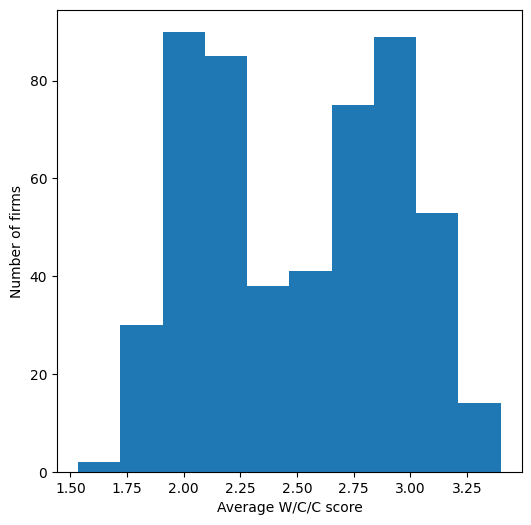

In [19]:
fig, ax = matplotlib.pyplot.subplots(figsize=(6,6))
ax.hist(client_average.to_numpy())
ax.set_xlabel('Average W/C/C score') #, weighted by prediction confidence
ax.set_ylabel('Number of firms')

Text(0, 0.5, 'Average W/C/C score')

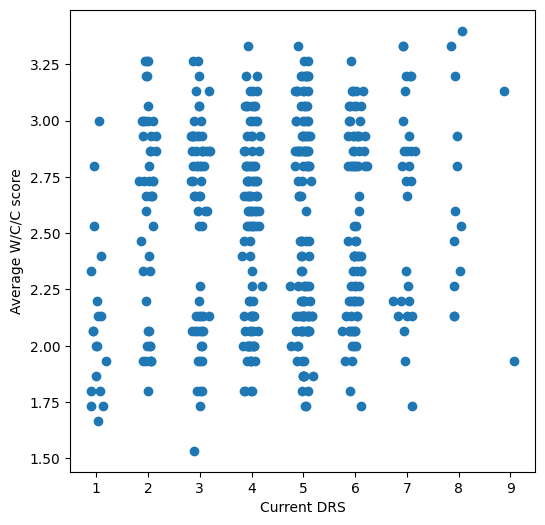

In [20]:
fig, ax = matplotlib.pyplot.subplots(figsize=(6,6))
X = per_client_results['Current DRS'].to_numpy().reshape(-1,1)
Y = per_client_results['Average'].to_numpy().reshape(-1,1)
ax.scatter(rand_jitter(X), Y)
ax.set_xlabel('Current DRS')
ax.set_ylabel('Average W/C/C score') #, weighted by prediction confidence